#Importing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score


# EDA & Cleaning


```
```



In [2]:
data=pd.read_csv("/content/Car details v3.csv")
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [4]:
data.shape

(8128, 13)

In [5]:
data.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [6]:
data.isna().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,221
engine,221


In [7]:
data.duplicated().sum()

np.int64(1202)

In [8]:
data.drop_duplicates(inplace=True)

In [9]:
data["mileage"]=data["mileage"].str.replace("kmpl","")
data["mileage"]=data["mileage"].str.replace("km/kg","")

In [10]:
data["mileage"] = pd.to_numeric(data["mileage"])

In [11]:
data["mileage"].dtypes

dtype('float64')

In [12]:
data["engine"]=data["engine"].str.replace("CC","")

In [13]:
data["engine"]=pd.to_numeric(data["engine"])

In [14]:
data["engine"].dtypes

dtype('float64')

In [15]:
data["max_power"]=data["max_power"].str.replace("bhp","")

In [16]:
data["max_power"] = data["max_power"].replace(" ", np.nan)

In [17]:
data["max_power"]=pd.to_numeric(data["max_power"])

Text(0.5, 1.0, 'Seller Type')

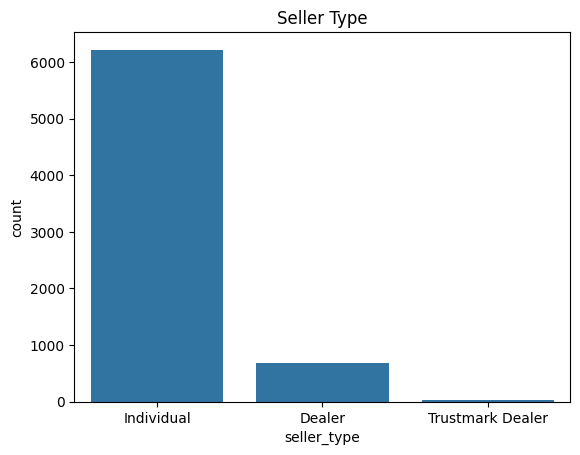

In [18]:
sns.countplot(data=data,x="seller_type")
plt.title("Seller Type")

Text(0.5, 1.0, 'Km_driven')

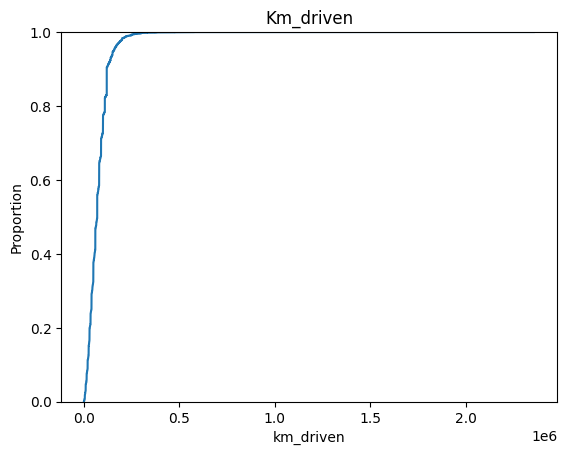

In [19]:
sns.ecdfplot(data=data,x="km_driven")
plt.title("Km_driven")

array([[<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'selling_price'}>,
        <Axes: title={'center': 'km_driven'}>],
       [<Axes: title={'center': 'mileage'}>,
        <Axes: title={'center': 'engine'}>,
        <Axes: title={'center': 'max_power'}>],
       [<Axes: title={'center': 'seats'}>, <Axes: >, <Axes: >]],
      dtype=object)

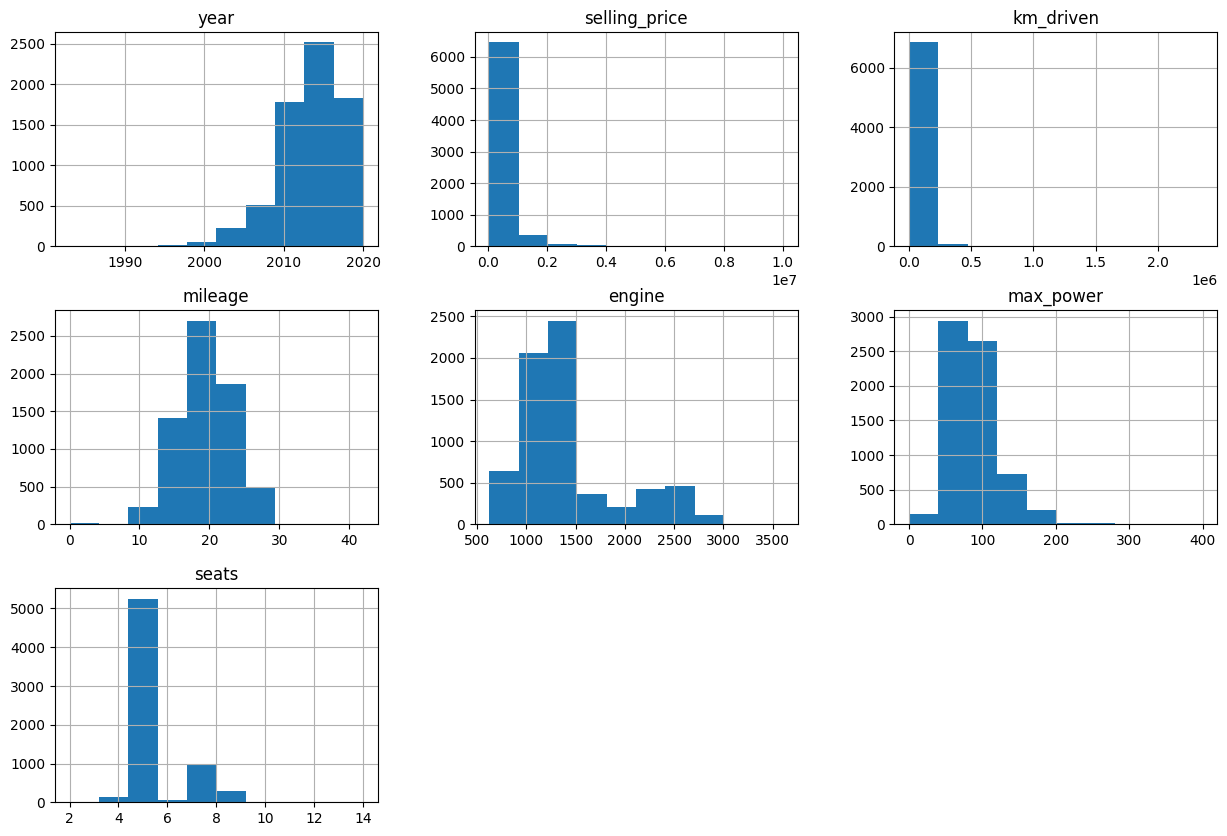

In [20]:
numerical_cols=data.select_dtypes(include="number").columns
data[numerical_cols].hist(figsize=(15, 10))

<Axes: >

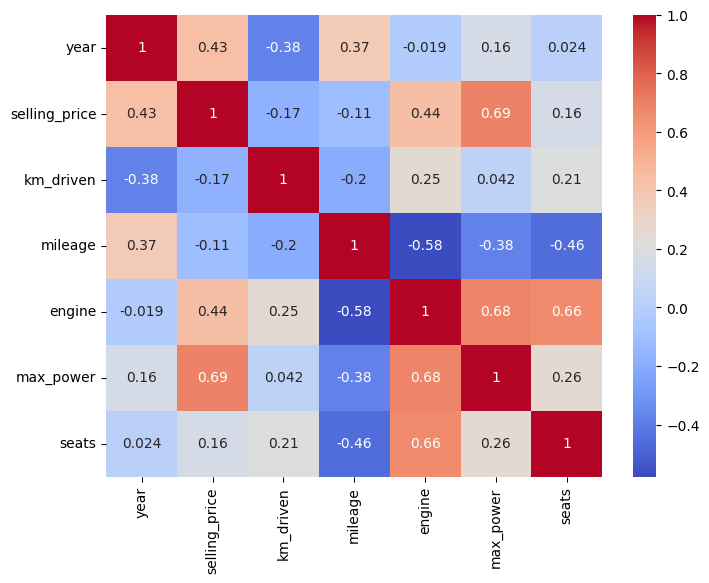

In [21]:

plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")

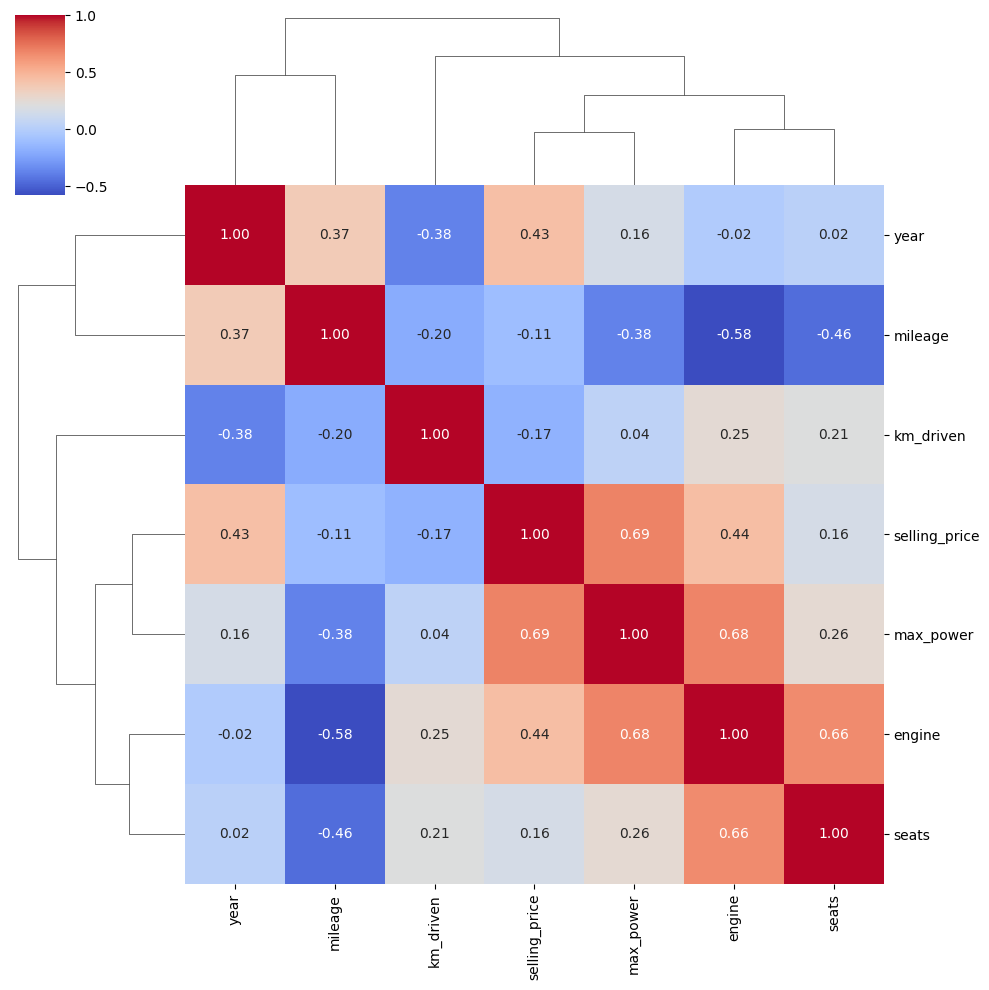

In [22]:
corr=data.select_dtypes("number").corr()
sns.clustermap(corr,annot=True,cmap="coolwarm",fmt=".2f")

Text(0.5, 1.0, 'Km_driven vs selling_price')

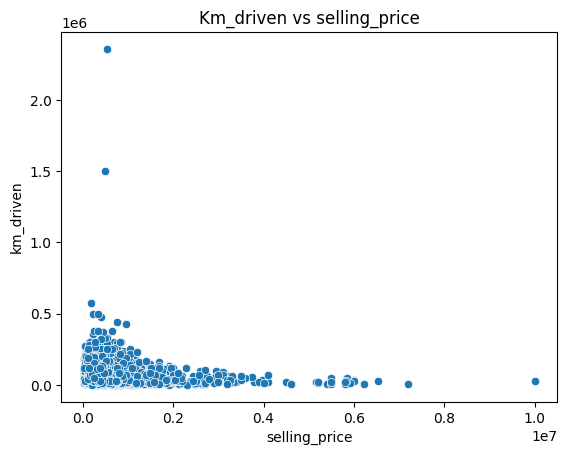

In [23]:
sns.scatterplot(data=data,x="selling_price",y="km_driven")
plt.title("Km_driven vs selling_price")

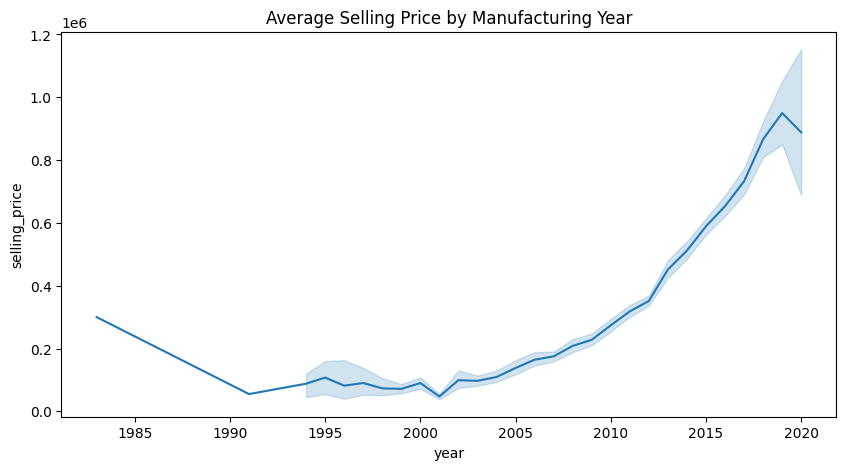

In [24]:
plt.figure(figsize=(10,5))
sns.lineplot(data=data, x="year", y="selling_price", estimator="mean")
plt.title("Average Selling Price by Manufacturing Year")
plt.show()

In [25]:
data.drop(columns="torque", inplace=True)

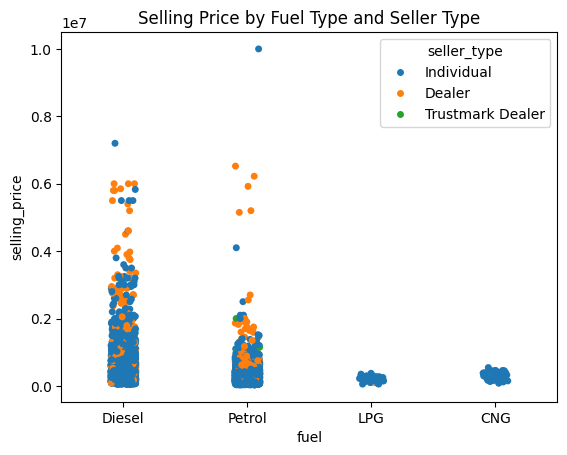

In [26]:
sns.stripplot(data=data,x="fuel",y="selling_price",hue="seller_type")
plt.title("Selling Price by Fuel Type and Seller Type")
plt.show()

# Train_test_split

In [27]:
X=data.drop("selling_price",axis=1)
y=data["selling_price"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [28]:
X_train.isnull().sum()

,0
name,0
year,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,172
engine,172
max_power,171


In [29]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    X_test[col] = X_test[col].fillna(median)

In [30]:
X_train["car_age"]=2026-X_train["year"]
X_test["car_age"]=2026-X_test["year"]

In [31]:
X_train.drop("year",inplace=True,axis=1)
X_test.drop("year",inplace=True,axis=1)

In [32]:
X_train["power_per_engine"]=X_train["max_power"]/X_train["engine"]
X_test["power_per_engine"]=X_test["max_power"]/X_test["engine"]

In [33]:
X_train["brand"] = X_train["name"].str.split().str[0]
X_test["brand"] = X_test["name"].str.split().str[0]

In [34]:
X_train.drop("name", axis=1, inplace=True)
X_test.drop("name", axis=1, inplace=True)

In [35]:
brand_counts = X_train["brand"].value_counts()

rare_brands = brand_counts[brand_counts < 20].index

X_train["brand"] = X_train["brand"].replace(rare_brands, "Other")
X_test["brand"] = X_test["brand"].replace(rare_brands, "Other")

In [36]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

In [37]:
(X_train["mileage"] == 0).sum()

np.int64(12)

In [38]:
mileage_median = X_train["mileage"].median()

X_train.loc[X_train["mileage"] == 0, "mileage"] = mileage_median
X_test.loc[X_test["mileage"] == 0, "mileage"] = mileage_median

In [39]:
(X_train["max_power"] == 0).sum()

np.int64(2)

In [40]:
power_median = X_train["max_power"].median()

X_train.loc[X_train["max_power"] == 0, "max_power"] = power_median
X_test.loc[X_test["max_power"] == 0, "max_power"] = power_median

In [41]:
#clip_cols = ["km_driven", "mileage", "engine", "max_power", "car_age"]

#for col in clip_cols:
    #Q1 = X_train[col].quantile(0.25)
    #Q3 = X_train[col].quantile(0.75)
    #IQR = Q3 - Q1
    #lower = Q1 - 1.5 * IQR
    #upper = Q3 + 1.5 * IQR

    #X_train[col] = X_train[col].clip(lower, upper)
    #X_test[col] = X_test[col].clip(lower, upper)

In [42]:
X_train["power_per_engine"] = X_train["max_power"] / X_train["engine"]
X_test["power_per_engine"] = X_test["max_power"] / X_test["engine"]

# Encoding

In [43]:
cat_cols=X_train.select_dtypes(include="object").columns

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_encoded = encoder.fit_transform(X_train[cat_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])

In [44]:

encoded_cols = encoder.get_feature_names_out(cat_cols)

X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_cols,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_cols,
    index=X_test.index
)

In [45]:
X_train = X_train.drop(cat_cols, axis=1)
X_test = X_test.drop(cat_cols, axis=1)

In [46]:
X_train = pd.concat([X_train, X_train_encoded], axis=1)
X_test = pd.concat([X_test, X_test_encoded], axis=1)

#Scaling

In [47]:
scaler=StandardScaler()
X_train_scalled=scaler.fit_transform(X_train)
X_test_scalled=scaler.transform(X_test)

# Modeling

# Model 1: Linear Reg

In [48]:
linear_model_raw = LinearRegression()
linear_model_raw.fit(X_train_scalled, y_train)

LinearRegression()

In [49]:
y_pred_linear_raw = linear_model_raw.predict(X_test_scalled)

In [50]:
mse_linear_raw=mean_squared_error(y_test,y_pred_linear_raw)
rmse_linear_raw=np.sqrt(mse_linear_raw)
mae_linear_raw=mean_absolute_error(y_test,y_pred_linear_raw)
r2_linear_raw=r2_score(y_test,y_pred_linear_raw)
print("MAE:", mae_linear_raw)
print("RMSE:", rmse_linear_raw)
print("R2:", r2_linear_raw)

MAE: 137836.30335056776
RMSE: 272055.4443753227
R2: 0.6625313905787547


## Model 2: Linear Regression (Log-Transformed Target)

In [51]:
y_train_log = np.log1p(y_train)

In [52]:
linear_model_log = LinearRegression()
linear_model_log.fit(X_train_scalled, y_train_log)

LinearRegression()

In [53]:
y_pred_linear_log_raw = linear_model_log.predict(X_test_scalled)

y_pred_linear_log = np.expm1(y_pred_linear_log_raw)

In [54]:
mae_linear_log = mean_absolute_error(y_test, y_pred_linear_log)
mae_linear_log

87655.26642167881

In [55]:
rmse_linear_log = np.sqrt(mean_squared_error(y_test, y_pred_linear_log))
r2_linear_log = r2_score(y_test, y_pred_linear_log)

print("RMSE:", rmse_linear_log)
print("R2:", r2_linear_log)

RMSE: 168867.93969180188
R2: 0.869979165680482


## Model 3: Ridge

In [56]:
ridge_model_log = Ridge(alpha=1)

ridge_model_log.fit(X_train_scalled, y_train_log)

Ridge(alpha=1)

In [57]:
y_pred_ridge_log_raw = ridge_model_log.predict(X_test_scalled)

y_pred_ridge_log = np.expm1(y_pred_ridge_log_raw)

In [58]:
mae_ridge_log = mean_absolute_error(y_test, y_pred_ridge_log)

rmse_ridge_log = np.sqrt(mean_squared_error(y_test, y_pred_ridge_log))

r2_ridge_log = r2_score(y_test, y_pred_ridge_log)

print("MAE:", mae_ridge_log)
print("RMSE:", rmse_ridge_log)
print("R2:", r2_ridge_log)

MAE: 87668.82874259364
RMSE: 168843.21549913098
R2: 0.8700172359599365


## Model 4: Random Forest

In [59]:
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train_scalled,y_train)

RandomForestRegressor(random_state=42)

In [60]:
y_predict_rf=rf.predict(X_test_scalled)

In [61]:
mae_rf=mean_absolute_error(y_test,y_predict_rf)
rmse_rf=np.sqrt(mean_squared_error(y_test,y_predict_rf))
r2_rf=r2_score(y_test, y_predict_rf)
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)


MAE: 73808.65159890859
RMSE: 133107.60567789694
R2: 0.919216199279722


## Model Comparison

In [62]:
comparison = pd.DataFrame({
    "linear_raw":    [mae_linear_raw, rmse_linear_raw, r2_linear_raw],
    "linear_log":    [mae_linear_log, rmse_linear_log, r2_linear_log],
    "ridge_log":     [mae_ridge_log,  rmse_ridge_log,  r2_ridge_log],
    "random_forest": [mae_rf,         rmse_rf,         r2_rf],
}, index=["MAE", "RMSE", "R2"]).T.sort_values("RMSE")

comparison

,MAE,RMSE,R2
random_forest,73808.651599,133107.605678,0.919216
ridge_log,87668.828743,168843.215499,0.870017
linear_log,87655.266422,168867.939692,0.869979
linear_raw,137836.303351,272055.444375,0.662531


## Save Best Model

In [63]:
import joblib
results = {
    "linear_raw":    {"model": linear_model_raw, "rmse": rmse_linear_raw, "uses_log": False},
    "linear_log":    {"model": linear_model_log, "rmse": rmse_linear_log, "uses_log": True},
    "ridge_log":     {"model": ridge_model_log,  "rmse": rmse_ridge_log,  "uses_log": True},
    "random_forest": {"model": rf,               "rmse": rmse_rf,        "uses_log": False},
}

best_name = min(results, key=lambda k: results[k]["rmse"])
best = results[best_name]

print(f"Best model: {best_name} (RMSE={best['rmse']:.2f})")

bundle = {
    "model": best["model"],
    "model_name": best_name,
    "uses_log_target": best["uses_log"],
    "scaler": scaler,
    "encoder": encoder,
    "cat_cols": list(cat_cols),
    "feature_columns": list(X_train.columns),
}

joblib.dump(bundle, "car_price_model.joblib")
print("Saved: car_price_model.joblib")

Best model: random_forest (RMSE=133107.61)
Saved: car_price_model.joblib
